In [8]:
from typing import Dict, List, Any
import numpy as np
from numpy.typing import NDArray
import pandas as pd

from model_ranking import (
    get_summary_results, 
    per_source_model_results,
    cmb_consistency_score_weighted_average,
)
from model_ranking import plot_alpha_sweep_specific_norm
from model_ranking import (
    calculate_correlation_statistics
)

In [9]:
per_source_consis_result_type =  Dict[str, Dict[str, Dict[str, NDArray[Any]]]]
per_source_performance_result_type = Dict[str, Dict[str, float]]
per_target_consis_result_type = Dict[str, per_source_consis_result_type]
per_target_performance_result_type = Dict[str, per_source_performance_result_type]

In [10]:
NA_UNet_source_models = {
    "EPFL": "E_model_NA2",
    "Hmito": "Hm_model_NA2",
    "Rmito": "Rm_model_NA2",
    "VNC": "V_model_NA2",
}
Res_source_models = {
    "EPFL": "E_model_Res1",
    "Hmito": "Hm_model_Res1",
    "Rmito": "Rm_model_Res1",
    "VNC": "V_model_Res1",
}
Unet_local_mean_source_models={
    "EPFL": "E_model4",
    "Hmito": "Hm_model3",
    "Rmito": "Rm_model3",
    "VNC": "V_model1",
}
Unet_global_mean_source_models={
    "EPFL": "E_model5",
    "Hmito": "Hm_model4",
    "Rmito": "Rm_model4",
    "VNC": "V_model2",
}
consis_keys={
    "EPFL": "EI_consis",
    "Hmito": "EI_consis",
    "Rmito": "EI_consis",
    "VNC": "EI_consis",
}
consis_keys_bckg = {
    "EPFL": "EI_consis_bckg",
    "Hmito": "EI_consis_bckg",
    "Rmito": "EI_consis_bckg",
    "VNC": "EI_consis_bckg",
}
result_folders={
    "EPFL": "FP_full",
    "Hmito": "FP_full",
    "Rmito": "FP_full",
    "VNC": "FP_full",
}

per_target_norms: Dict[str, List[None]] = {
    "EPFL": [None],
    "Hmito": [None],
    "Rmito": [None],
    "VNC": [None],
}

perf_key = "hard_f1"
approach="feature_perturbation_consistency"
base_result_path = "/scratch/talks/consistency_results/patch_segmentation/mitochondria"

In [11]:
summary_results_postfix = "_full"
selected_augmentations = {
    "none": [""],
    "DO": ["a0001", "a0005", "a001", "a002", "a003", "a004", "a005", "a01"],
}
targets = ["EPFL", "Hmito", "Rmito", "VNC"]
source_model_types = [NA_UNet_source_models, Res_source_models, Unet_local_mean_source_models, Unet_global_mean_source_models]

In [12]:
per_target_forg_consistency: per_target_consis_result_type= {}
per_target_forg_performance: per_target_performance_result_type = {}
for i, target in enumerate(targets):
    if target == "VNC":
        sources = ["EPFL", "Hmito", "Rmito"]
    else:
        sources = ["EPFL", "Hmito", "Rmito", "VNC"]
    per_source_forg_consistency = {}
    per_source_forg_performance = {}

    for model_type in source_model_types:

        consis_str, _, NA_perf = get_summary_results(
            source_data=sources,
            target_data=[target],
            source_models = model_type,
            selected_augmentations=selected_augmentations,
            selected_norms=per_target_norms,
            consis_keys=consis_keys,
            perf_key=perf_key,
            per_target_norms=True,
            result_folders=result_folders,
            approach=approach,
            consis_postfix="median",
            perf_postfix="median",
            summary_results_postfix=summary_results_postfix,
            base_seg_dir=base_result_path,
        )
        per_source_forg_consistency.update(
            per_source_model_results(
                consis_str, 
                source_models=model_type, 
            ))
        per_source_forg_performance.update(
            per_source_model_results(
                NA_perf, 
                source_models=model_type,
            ))
    
    per_target_forg_consistency[target] = per_source_forg_consistency
    per_target_forg_performance[target] = per_source_forg_performance


Source: EPFL


100%|██████████| 1/1 [00:00<00:00, 18.10it/s]


Source: Hmito


100%|██████████| 1/1 [00:00<00:00, 11.67it/s]


Source: Rmito


...

100%|██████████| 1/1 [00:00<00:00, 20.75it/s]


Source: Hmito


100%|██████████| 1/1 [00:00<00:00, 18.49it/s]


Source: Rmito


100%|██████████| 1/1 [00:00<00:00, 22.78it/s]


In [14]:
per_target_bckg_consistency: Dict[str, Dict[str, Dict[str, Dict[str, NDArray[Any]]]]] = {}
per_target_bckg_performance: Dict[str, Dict[str, Dict[str, NDArray[Any]]]] = {}

for i, target in enumerate(targets):
    if target == "VNC":
        sources = ["EPFL", "Hmito", "Rmito"]
    else:
        sources = ["EPFL", "Hmito", "Rmito", "VNC"]
    per_source_bckg_consistency = {}
    per_source_bckg_performance = {}

    for model_type in source_model_types:

        consis_str, _, NA_perf = get_summary_results(
            source_data=sources,
            target_data=[target],
            source_models = model_type,
            selected_augmentations=selected_augmentations,
            selected_norms=per_target_norms,
            consis_keys=consis_keys_bckg,
            perf_key=perf_key,
            per_target_norms=True,
            result_folders=result_folders,
            approach=approach,
            consis_postfix="median",
            perf_postfix="median",
            summary_results_postfix=summary_results_postfix,
            base_seg_dir=base_result_path,
        )
        per_source_bckg_consistency.update(
            per_source_model_results(
                consis_str, 
                source_models=model_type, 
            ))
        per_source_bckg_performance.update(
            per_source_model_results(
                NA_perf, 
                source_models=model_type,
            ))
        
    
    per_target_bckg_consistency[target] = per_source_bckg_consistency
    per_target_bckg_performance[target] = per_source_bckg_performance

    

Source: EPFL


100%|██████████| 1/1 [00:00<00:00, 27.42it/s]


Source: Hmito


100%|██████████| 1/1 [00:00<00:00, 13.23it/s]


Source: Rmito


...

100%|██████████| 1/1 [00:00<00:00, 28.93it/s]


Source: Hmito


100%|██████████| 1/1 [00:00<00:00, 26.62it/s]


Source: Rmito


100%|██████████| 1/1 [00:00<00:00, 23.88it/s]


In [15]:
per_target_cmb_consistency = cmb_consistency_score_weighted_average(
    per_target_forg_consistency,
    per_target_bckg_consistency,
    w_fg=0.5,
    w_bg=0.5,
)

In [16]:
per_target_KT = np.zeros((len(targets), len(selected_augmentations["DO"]), 2))
per_target_SP = np.zeros((len(targets), len(selected_augmentations["DO"]), 2))
per_target_PE = np.zeros((len(targets), len(selected_augmentations["DO"]), 2))
for i, target in enumerate(targets):
    (per_target_KT[i], 
        per_target_SP[i], 
        per_target_PE[i]
    ) = calculate_correlation_statistics(
            per_target_cmb_consistency[target],
            per_target_forg_performance[target],
            selected_augmentations,
            perturbation_key="DO",
        )

In [18]:
aug_strengths = selected_augmentations["DO"]
for aug_strength in aug_strengths:
    idx = selected_augmentations["DO"].index(aug_strength)
    df = pd.DataFrame(
        {
            "kt": per_target_KT[:, idx, 0], 
            "kt pval": per_target_KT[:, idx, 1], 
            "s rho": per_target_SP[:, idx, 0], 
            "s rho pval": per_target_SP[:, idx, 1], 
            "pr": per_target_PE[:, idx, 0], 
            "pr pval": per_target_PE[:, idx, 1]
        },
    )
    df["targets"] = targets
    df = df.set_index("targets")
    df.index = pd.MultiIndex.from_product([["Mito"], df.index], names=["Task", "targets"])
    # Round all float columns to 2 significant figures
    df = df.map(lambda x: round(x, 2) if isinstance(x, float) else x)
    print(f"Augmentation strength: DO {aug_strength}")
    print(df)

Augmentation strength: DO a0001
                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito EPFL     0.92     0.00   0.90        0.00  0.73     0.00
     Hmito    0.76     0.00   0.78        0.00  0.58     0.00
     Rmito    0.92     0.00   0.89        0.00  0.74     0.00
     VNC      0.74     0.01   0.65        0.02  0.45     0.06
Augmentation strength: DO a0005
                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito EPFL     0.92      0.0   0.90        0.00  0.73     0.00
     Hmito    0.76      0.0   0.78        0.00  0.58     0.00
     Rmito    0.94      0.0   0.90        0.00  0.74     0.00
     VNC      0.75      0.0   0.63        0.04  0.39     0.08
Augmentation strength: DO a001
                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito EPFL     0.94     0.00   0.92   

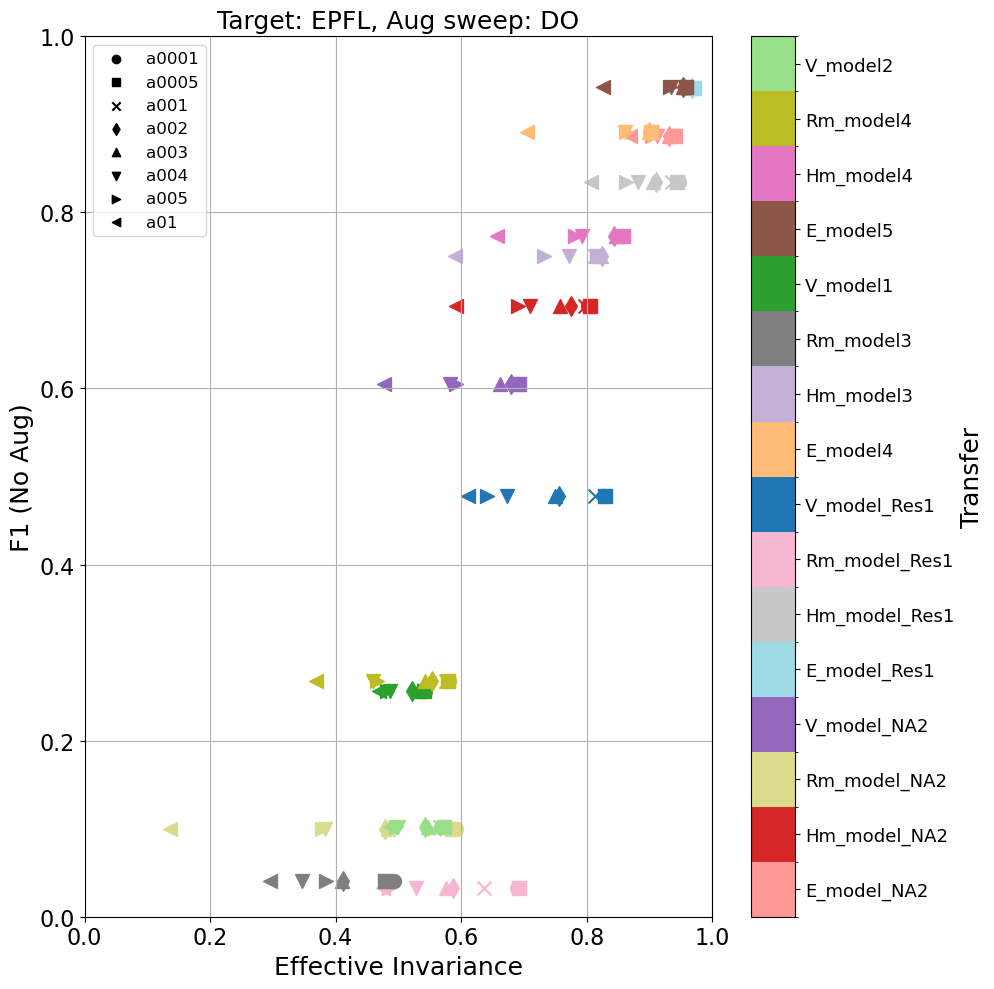

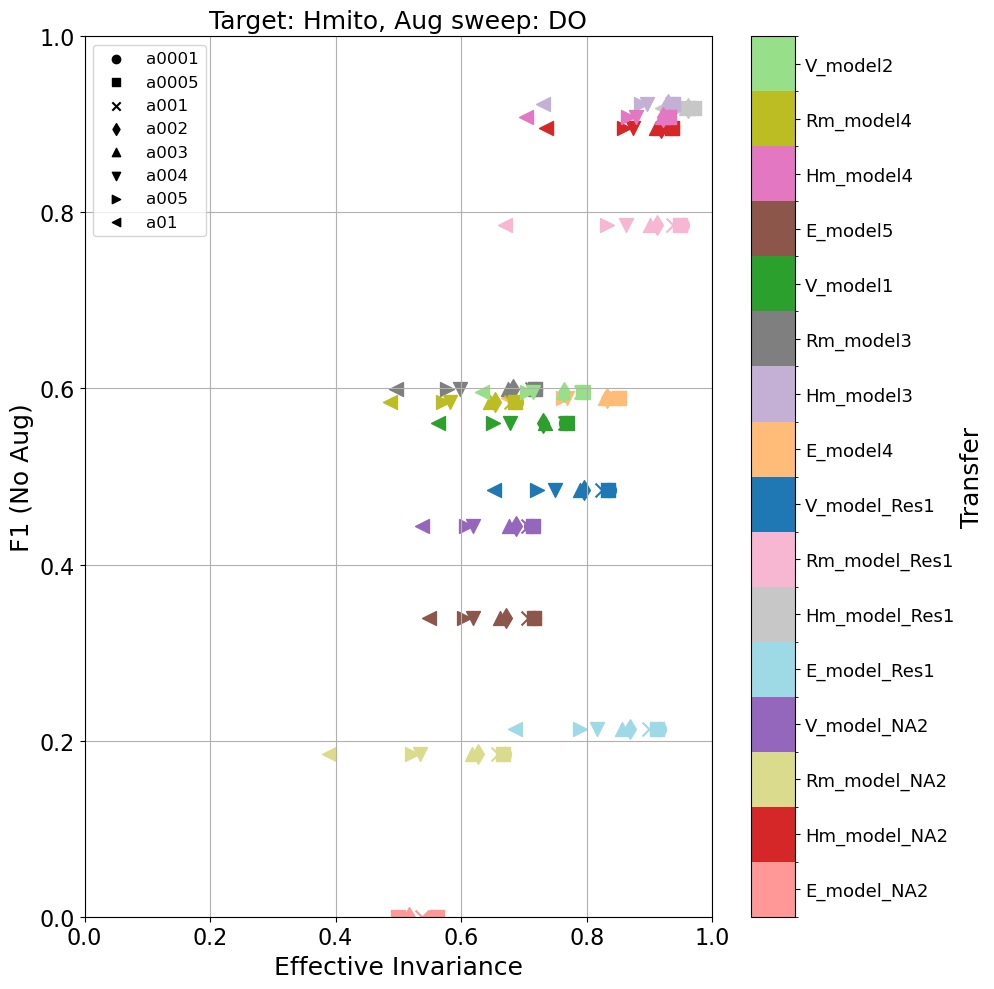

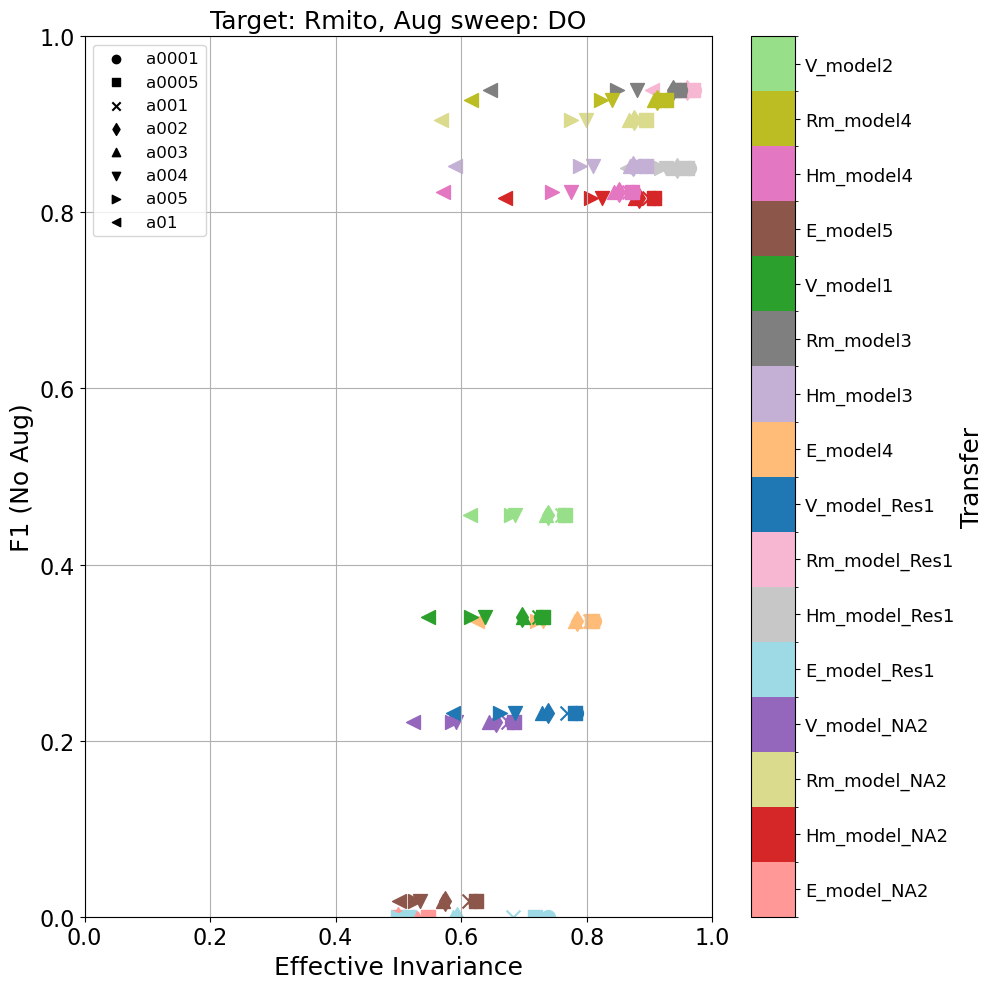

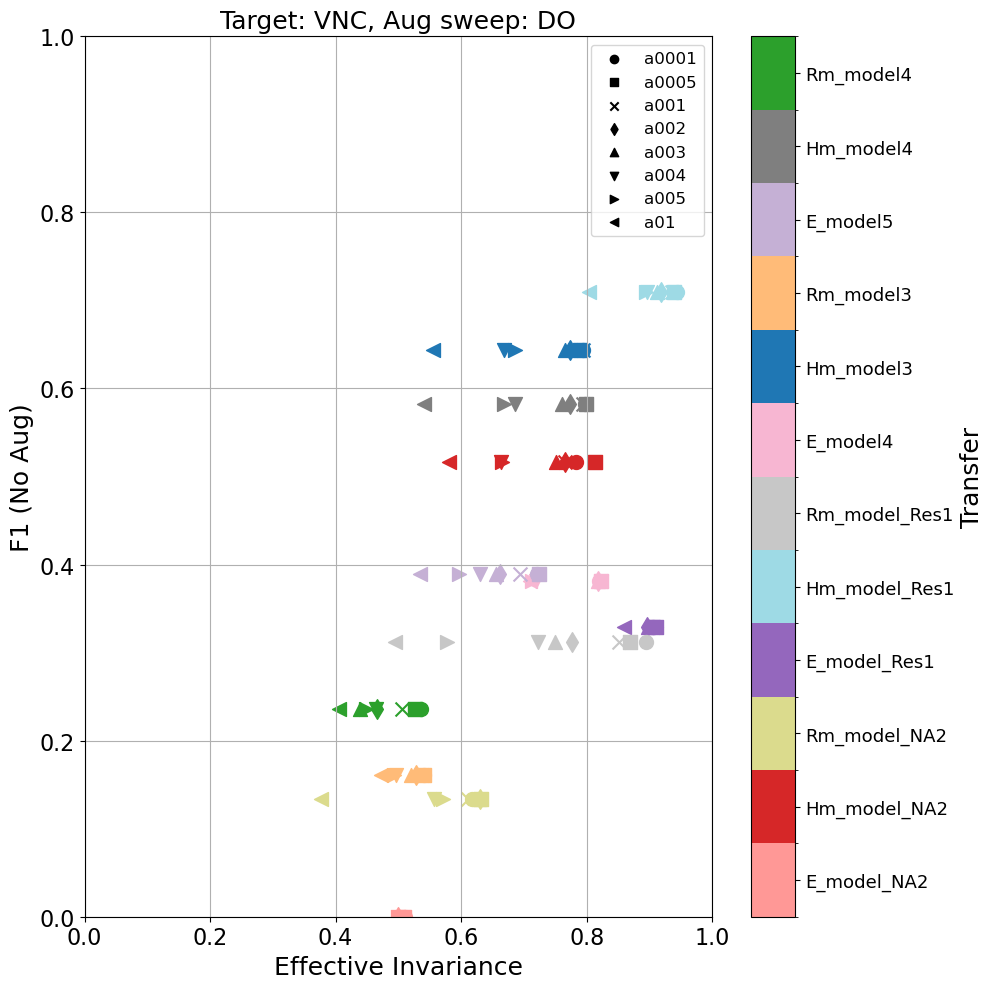

In [17]:
for target in targets:
    plot_alpha_sweep_specific_norm(
        per_target_cmb_consistency[target],
        per_target_forg_performance[target],
        augs=["DO"],
        select_alphas=selected_augmentations,
        select_norms=per_target_norms,
        consistency_metric_name="Effective Invariance",
        invert_consis_metric= False,
        invert_perf_metric=False,
        pos_correlation_line=False,
        per_transfer_norms=False,
        single_target=target,
        xlim=(0, 1),
        n_rows=1,
        n_cols = 1,
    )
(
    pearson_scores, 
    spearman_scores, 
    kendall_tau_scores
) = calculate_correlation_statistics(
        per_target_cmb_consistency[target],
        per_target_forg_performance[target],
        selected_augmentations,
        perturbation_key="DO",
    )
